<a href="https://colab.research.google.com/github/rajmishra-dev/python-project/blob/main/bayes_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probability with Python


# Q.1 Given that a


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bayes_theorem_student_dataset.csv to bayes_theorem_student_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("bayes_theorem_student_dataset.csv")

df

,Student,Background,ML_Exposure
0,S1,Science,Yes
1,S2,Science,Yes
2,S3,Science,No
3,S4,Science,Yes
4,S5,Science,No
5,S6,Engineering,Yes
6,S7,Engineering,No
7,S8,Engineering,Yes
8,S9,Engineering,No
9,S10,Engineering,Yes


# Calculate the Prior Probability

P(Science) —

The probability of a student being from a Science background before considering ML exposure.

In [ ]:
science_count = (df["Background"] == "Science").sum()
total_students = len(df)

prior_science = science_count / total_students

print("Science students:", science_count)
print("Total students:", total_students)
print("P(Science):", prior_science)

Science students: 10
Total students: 20
P(Science): 0.5


# Expected Output :

Science students: 10
Total students: 20
P(Science): 0.5

# Model Evaluation Using Confusion Matrix and Classification Report

Accuracy: 25.00%


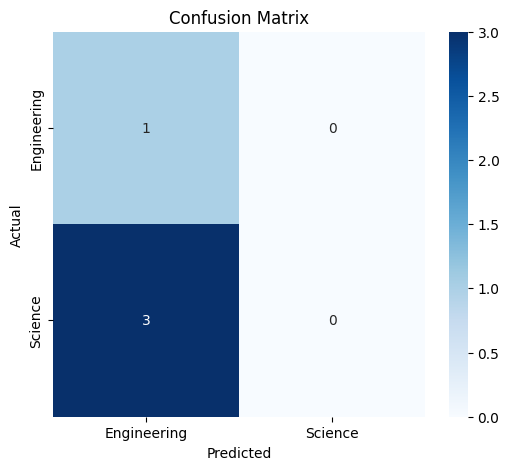


Classification Report:

              precision    recall  f1-score   support

 Engineering       0.25      1.00      0.40         1
     Science       0.00      0.00      0.00         3

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("bayes_theorem_student_dataset.csv")

# Convert categorical data into numbers
encoder = LabelEncoder()

df["Background"] = encoder.fit_transform(df["Background"])
df["ML_Exposure"] = encoder.fit_transform(df["ML_Exposure"])

# Features and target
X = df[["ML_Exposure"]]
y = df["Background"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train model
model = CategoricalNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Engineering", "Science"],
    yticklabels=["Engineering", "Science"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Engineering", "Science"]
    )
)